In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("disease_diagnosis.csv")

In [3]:
print(data.head())

   Patient_ID  Age  Gender            Symptom_1    Symptom_2 Symptom_3  \
0           1   74    Male              Fatigue  Sore throat     Fever   
1           2   66  Female          Sore throat      Fatigue     Cough   
2           3   32    Male            Body ache  Sore throat   Fatigue   
3           4   21  Female  Shortness of breath     Headache     Cough   
4           5   53    Male           Runny nose  Sore throat   Fatigue   

   Heart_Rate_bpm  Body_Temperature_C Blood_Pressure_mmHg  \
0              69                39.4              132/91   
1              95                39.0              174/98   
2              77                36.8              136/60   
3              72                38.9              147/82   
4             100                36.6             109/106   

   Oxygen_Saturation_% Diagnosis  Severity       Treatment_Plan  
0                   94       Flu  Moderate  Medication and rest  
1                   98   Healthy      Mild      Rest and

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.3+ KB
None


In [5]:
print(data.isnull().sum())

Patient_ID             0
Age                    0
Gender                 0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Heart_Rate_bpm         0
Body_Temperature_C     0
Blood_Pressure_mmHg    0
Oxygen_Saturation_%    0
Diagnosis              0
Severity               0
Treatment_Plan         0
dtype: int64


In [6]:
print(data.describe())

        Patient_ID          Age  Heart_Rate_bpm  Body_Temperature_C  \
count  2000.000000  2000.000000     2000.000000         2000.000000   
mean   1000.500000    48.285000       89.439000           37.741000   
std     577.494589    17.422616       17.139608            1.309835   
min       1.000000    18.000000       60.000000           35.500000   
25%     500.750000    33.000000       75.000000           36.600000   
50%    1000.500000    49.000000       89.000000           37.700000   
75%    1500.250000    63.000000      104.000000           38.900000   
max    2000.000000    79.000000      119.000000           40.000000   

       Oxygen_Saturation_%  
count          2000.000000  
mean             94.493500  
std               2.861827  
min              90.000000  
25%              92.000000  
50%              95.000000  
75%              97.000000  
max              99.000000  


In [7]:
data = data.drop(["Patient_ID", "Treatment_Plan"], axis=1)

In [8]:
data[['Systolic_BP','Diastolic_BP']] = data['Blood_Pressure_mmHg'].str.split('/', expand=True)

data['Systolic_BP'] = data['Systolic_BP'].astype(int)
data['Diastolic_BP'] = data['Diastolic_BP'].astype(int)
data = data.drop("Blood_Pressure_mmHg", axis=1)

In [9]:
print(data.head())

   Age  Gender            Symptom_1    Symptom_2 Symptom_3  Heart_Rate_bpm  \
0   74    Male              Fatigue  Sore throat     Fever              69   
1   66  Female          Sore throat      Fatigue     Cough              95   
2   32    Male            Body ache  Sore throat   Fatigue              77   
3   21  Female  Shortness of breath     Headache     Cough              72   
4   53    Male           Runny nose  Sore throat   Fatigue             100   

   Body_Temperature_C  Oxygen_Saturation_% Diagnosis  Severity  Systolic_BP  \
0                39.4                   94       Flu  Moderate          132   
1                39.0                   98   Healthy      Mild          174   
2                36.8                   96   Healthy      Mild          136   
3                38.9                   99   Healthy      Mild          147   
4                36.6                   92   Healthy      Mild          109   

   Diastolic_BP  
0            91  
1            98  
2 

In [10]:
print(data.columns)

Index(['Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%',
       'Diagnosis', 'Severity', 'Systolic_BP', 'Diastolic_BP'],
      dtype='object')


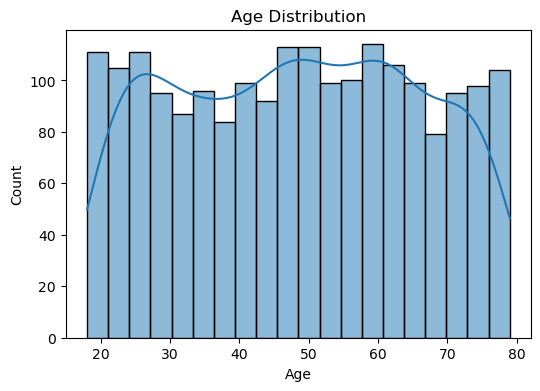

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(data["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

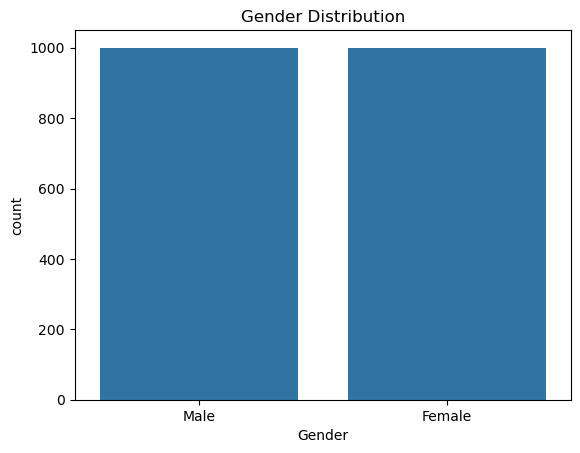

In [12]:
sns.countplot(x="Gender", data=data)

plt.title("Gender Distribution")

plt.show()

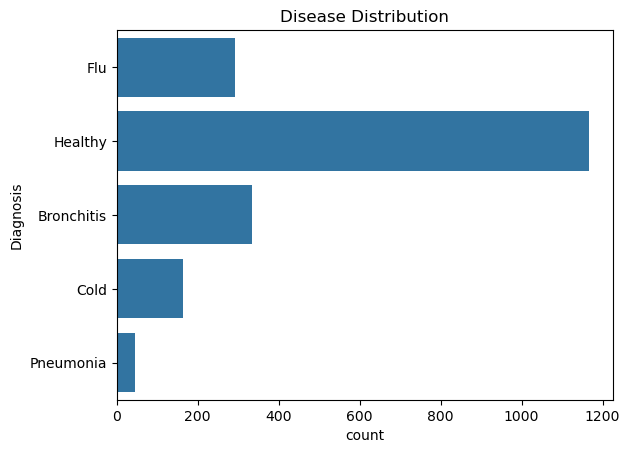

In [13]:
sns.countplot(y="Diagnosis", data=data)

plt.title("Disease Distribution")

plt.show()

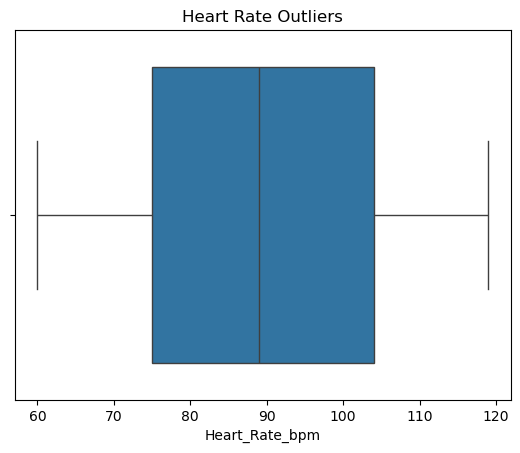

In [14]:
sns.boxplot(x=data["Heart_Rate_bpm"])

plt.title("Heart Rate Outliers")

plt.show()

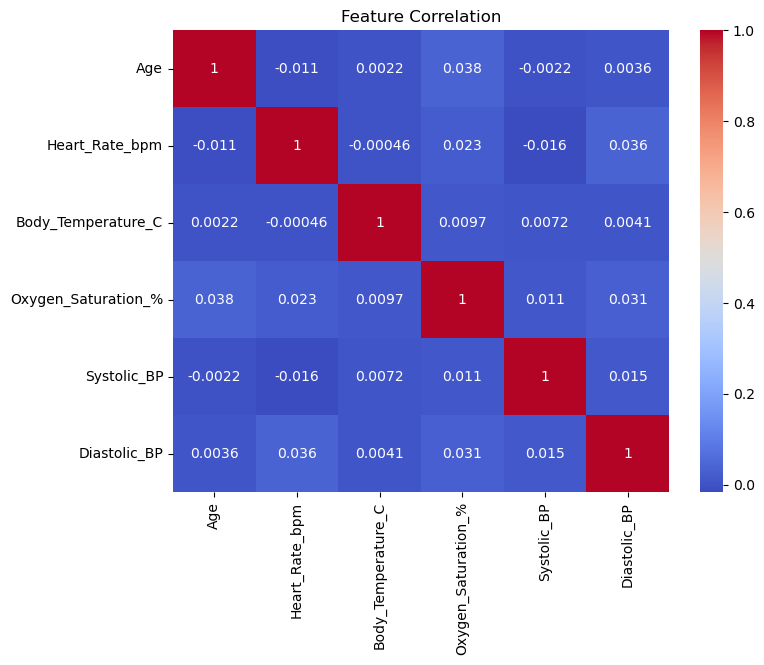

In [15]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

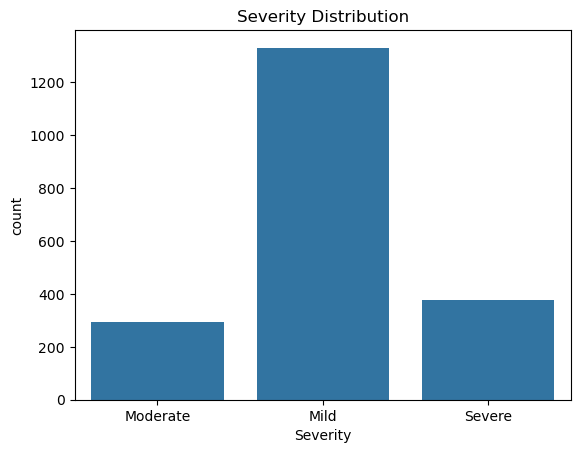

In [16]:
sns.countplot(x="Severity", data=data)

plt.title("Severity Distribution")
plt.show()

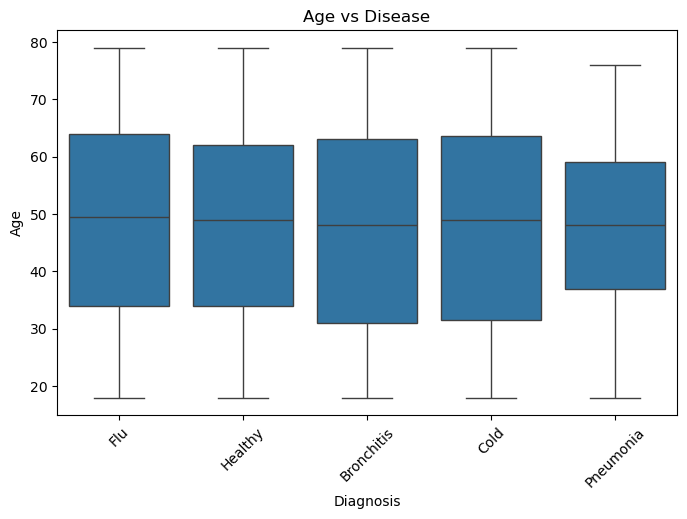

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Diagnosis", y="Age", data=data)

plt.title("Age vs Disease")
plt.xticks(rotation=45)
plt.show()

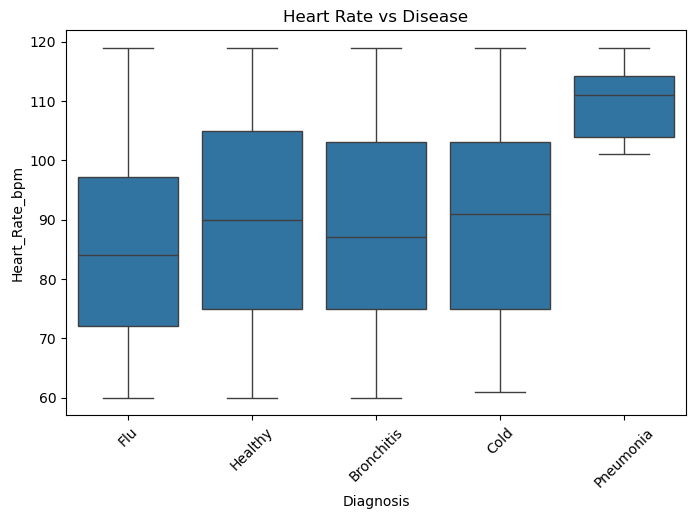

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Diagnosis", y="Heart_Rate_bpm", data=data)

plt.title("Heart Rate vs Disease")
plt.xticks(rotation=45)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
data["Health_Index"] = (
    data["Heart_Rate_bpm"] +
    data["Body_Temperature_C"] -
    data["Oxygen_Saturation_%"]
)

In [21]:
data = pd.get_dummies(data, columns=["Symptom_1", "Symptom_2", "Symptom_3"])

# Label Encoding for target + gender
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])
data["Diagnosis"] = le.fit_transform(data["Diagnosis"])
data["Severity"] = le.fit_transform(data["Severity"])


In [22]:

X = data.drop(["Diagnosis"], axis=1)
y = data["Diagnosis"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [25]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [26]:

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [27]:
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Decision Tree Accuracy: 0.9975
Random Forest Accuracy: 0.9925


In [28]:
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Decision Tree Accuracy: 0.9975
Random Forest Accuracy: 0.9925


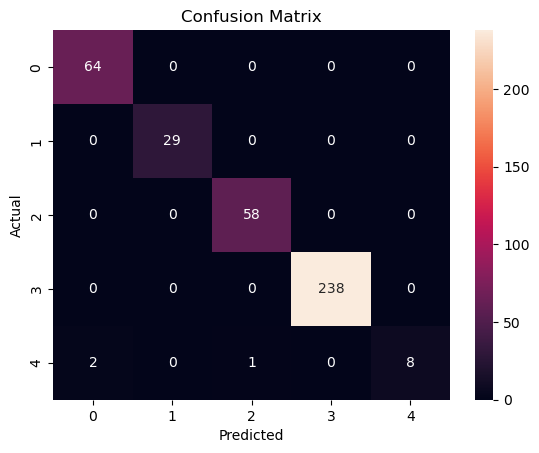

In [29]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

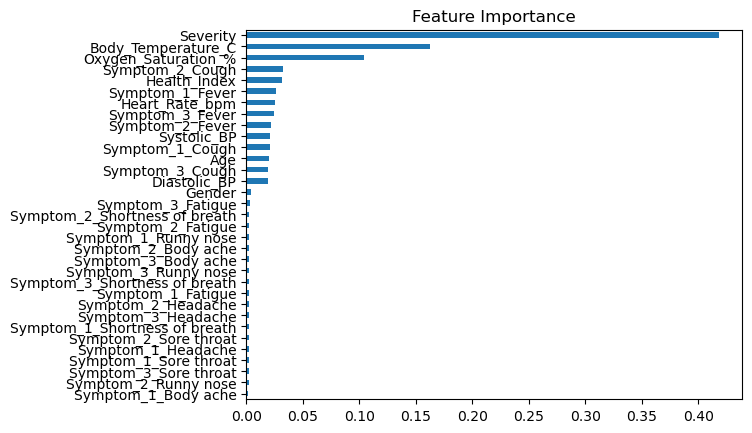

In [30]:

importance = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [31]:

def predict_disease(sample):
    prediction = rf_model.predict([sample])
    return prediction

In [32]:
sample = X_test.iloc[0]
print("\nSample Prediction:", predict_disease(sample))


Sample Prediction: [0]


c:\Users\KUSHESH GANGWAR\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
